In [2]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'


import torch
from hydra.utils import instantiate
from hydra import initialize, compose
import hydra

import wandb

from data.dataManager import DataManager
from model.modelCreator import ModelCreator
from omegaconf import OmegaConf
from scripts.run import setup_model, load_model_instance
from model.rbm.rbm_two_partite import RBM_TwoPartite

from utils.dwave.experiments import run_hamming_cliff_classical_only
from utils.dwave.plots import plot_hamming_magnetization_classical, plot_hamming_correlations_classical, plot_hamming_cliff_comparison
from utils.pca_utils import load_data, run_pca_pipeline, load_data_features,orchestrate_basis_evaluation
from utils.rbm.rbm_plots import plot_pca_analysis, prepare_dataframe, plot_pca_analysis_with_energy, prepare_dataframe_incident_energy, plot_pca_analysis_with_features, prepare_dataframe_features, plot_weight_distribution, plot_basis_evaluation, prepare_dataframe_pls, plot_pls_analysis, plot_pls_loadings, plot_pls_r2, prepare_dataframe_sir, plot_sir_analysis, plot_sir_spectrum, plot_lv_feature_scatter, plot_lv_quantile_tracking, plot_tail_weighting, plot_weight_distribution_checkpoints

from datetime import datetime
import os
from scripts.RBM_2P_MNIST import save_clamped_samples_for_vae
from utils.rbm.rbm_utils import run_pls_pipeline, calculate_pls_r2, run_sir_pipeline
from utils.latent_dataset import LatentDataset



/usr/local/lib/python3.12/dist-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
[18:47:56.502] INFO   CaloQuVAE                                         Loading configuration.
[18:47:58.135] INFO   numexpr.utils                                     Note: detected 96 virtual cores but NumExpr set to maximum of 64, check "NUMEXPR_MAX_THREADS" environment variable.
[18:47:58.136] INFO   numexpr.utils                                     Note: NumExpr detected 96 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
[18:47:58.137] INFO   numexpr.utils                                     NumExpr defaulting to 16 threads.


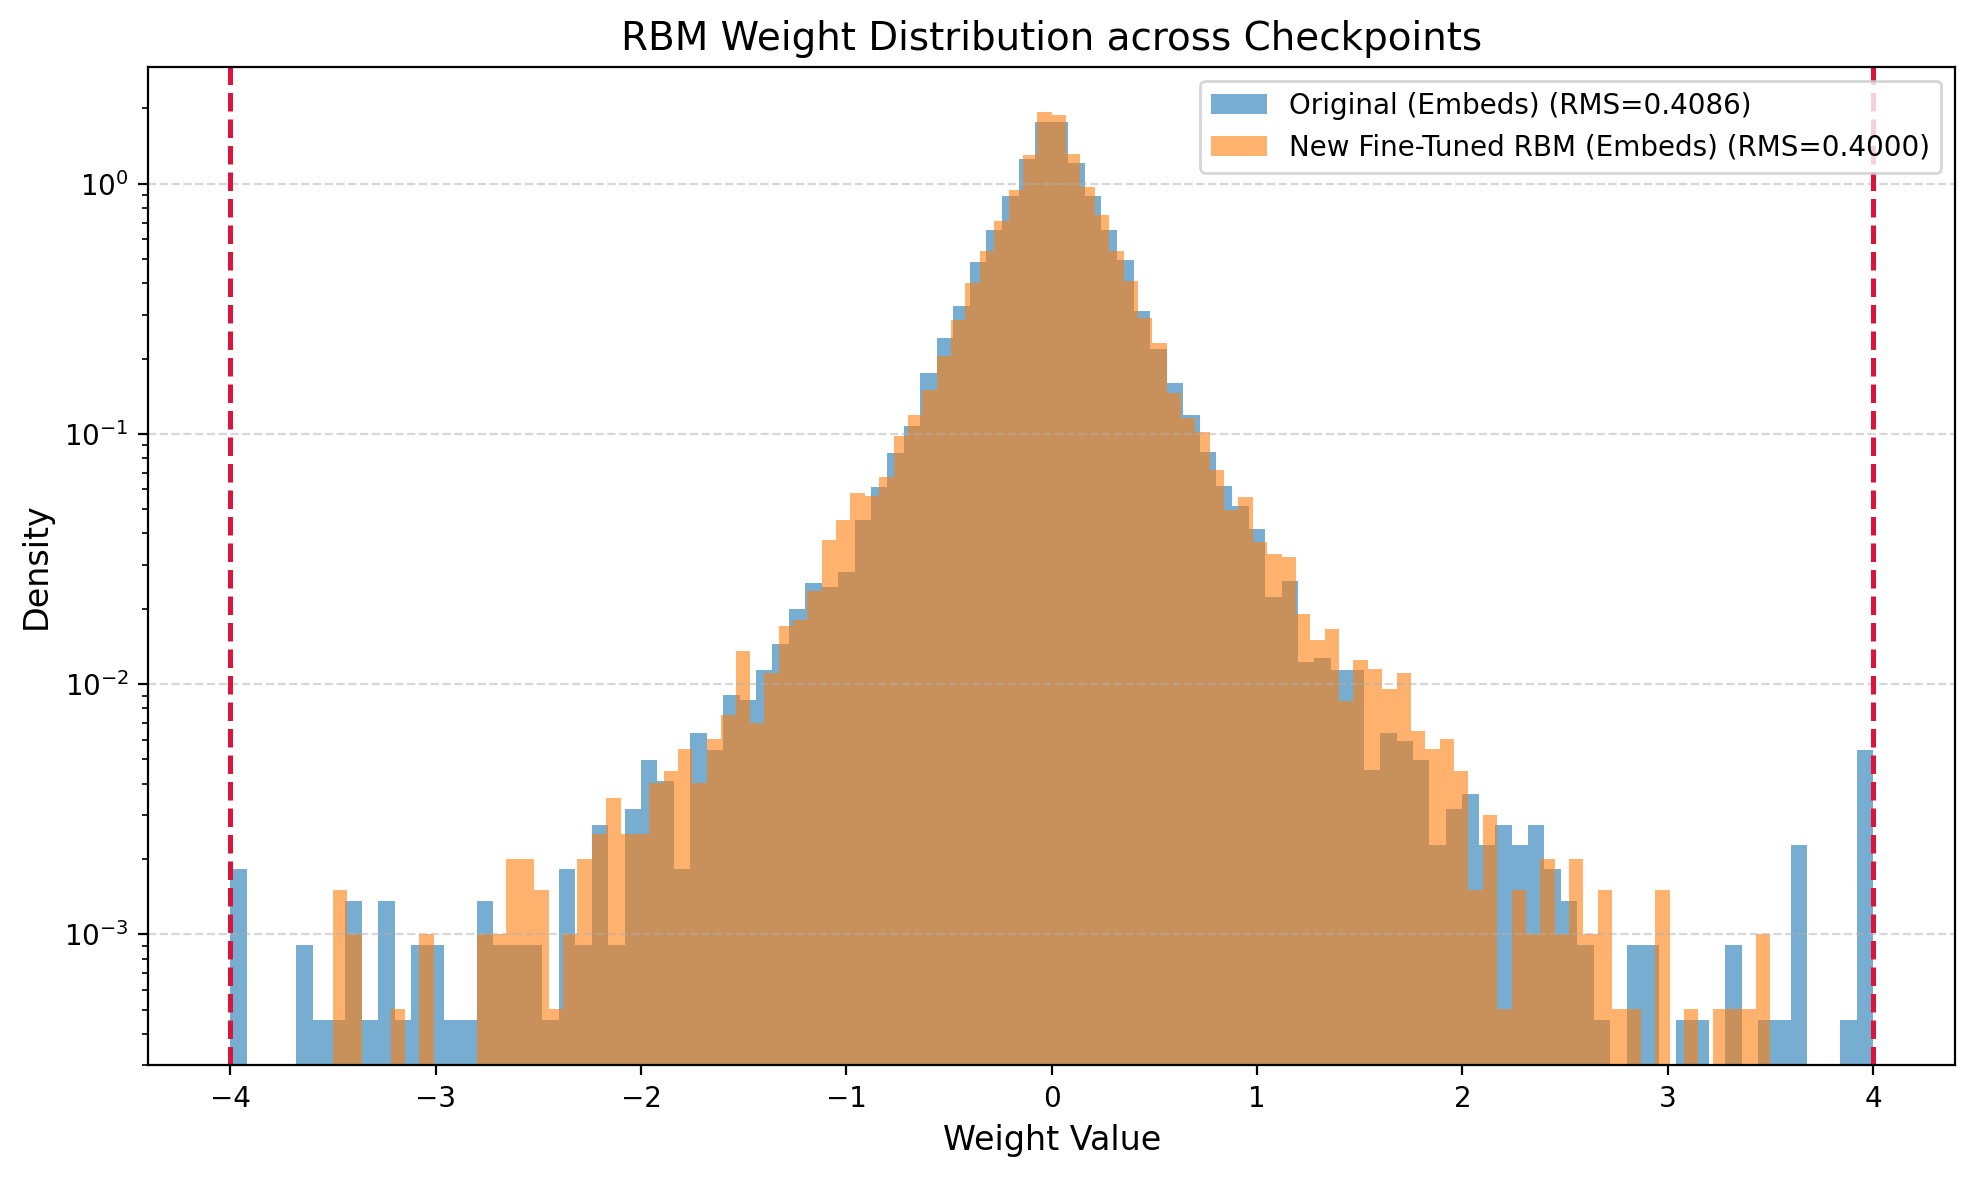

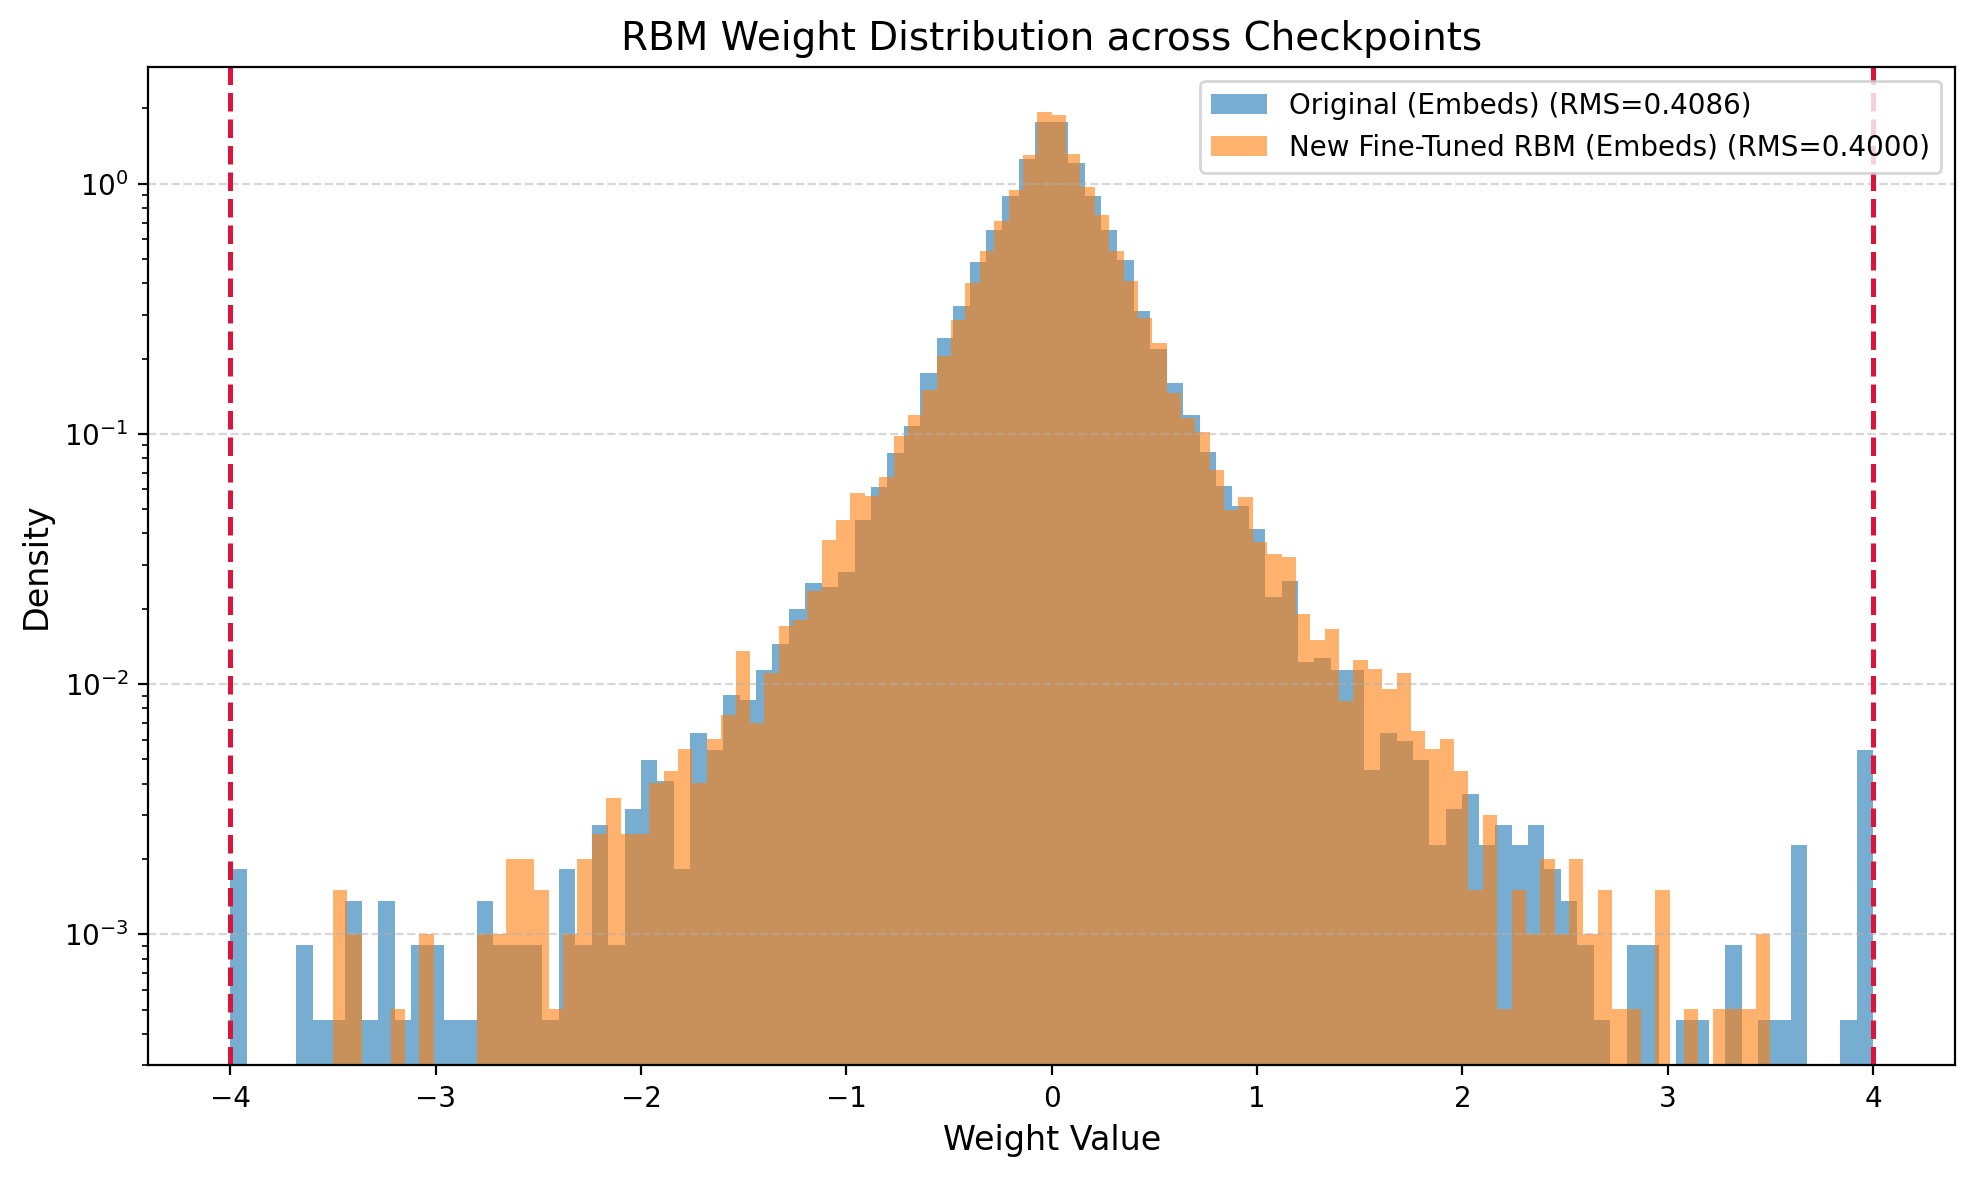

In [9]:
checkpoint_paths = [
    "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-02_22-31-04_RBM_TwoPartite/training_checkpoint_epoch_4000.h5",
    # "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-14_20-57-02_RBM_TwoPartite/training_checkpoint_epoch_4000.h5",
    # "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-15_00-08-50_RBM_TwoPartite/training_checkpoint_epoch_4000.h5",
    # "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-15_00-09-20_RBM_TwoPartite/training_checkpoint_epoch_4000.h5",
    # # "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-15_22-33-23_RBM_TwoPartite/training_checkpoint_epoch_4000.h5",
    # # "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-15_22-34-46_RBM_TwoPartite/training_checkpoint_epoch_4000.h5",
    # # "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-15_22-36-17_RBM_TwoPartite/training_checkpoint_epoch_4000.h5",
    # # "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-17_18-49-28_RBM_MPF/training_checkpoint_epoch_4000.h5",
    # # "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-19_05-30-47_RBM_MPF/training_checkpoint_epoch_4000.h5"
    # # "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-17_18-48-18_RBM_MPF/training_checkpoint_epoch_4000.h5",
    # # "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-20_20-52-54_RBM_MPF/training_checkpoint_epoch_512.h5",
    # "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-21_00-25-42_RBM_MPF/training_checkpoint_epoch_4000.h5",
    # "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-21_18-08-54_RBM_MPF/training_checkpoint_epoch_4000.h5",
    # "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-22_18-29-29_RBM_MPF/training_checkpoint_epoch_100.h5",
    # "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-21_18-04-46_RBM_MPF/training_checkpoint_epoch_4000.h5",
    # "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-21_18-09-13_RBM_MPF/training_checkpoint_epoch_4000.h5"
    "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-22_21-23-45_RBM_MPF/training_checkpoint_epoch_500.h5"
]
labels = [
    "Original (Embeds)",
    # "Importance Weighing",
    # "MPF",
    # "MPF + Importance Weighing (Doesn't Embed)",
    # "Decayed MPF + Importance Weighing",
    # "Decayed Weighted",
    # "Decayed Weighted 2"
    # "MPF Decayed (5e-6)",
    # "MPF Decayed (2e-5)"
    # "MPF Decayed (2e-6)",
    # "MPF Fine-Tuned"
    # "MPF + Importance Weighing + Clipping (Embeds)",
    # "New RBM (Doesn't Embed)",
    # "3.5, Fine-Tuned"
    # "3.75 (New)",
    # "4.0 (New)"
    # "New RBM "
    "New Fine-Tuned RBM (Embeds)"
    ]
plot_weight_distribution_checkpoints(checkpoint_paths, labels, abs_tol=4.0)

In [ ]:
FEATURES_PATHS = [
  "/home/leozhu/CaloQuVAE/wandb-outputs/latent_train_eta_layer1_2026-04-21_17-45-22_data.pt",
  "/home/leozhu/CaloQuVAE/wandb-outputs/latent_train_eta_layer2_2026-04-21_17-45-22_data.pt"
]
TAIL_THRESHOLD = 2e-3

# 1. Build the dataset exactly as training does
dataset = LatentDataset(
data_path="/home/leozhu/CaloQuVAE/wandb-outputs/latent_train_data_2026-04-21_17-45-22_compact.pt",
features_paths=FEATURES_PATHS,
tail_threshold=TAIL_THRESHOLD,
weight_alpha=2.0,
weight_max=150.0
)

# 2. Re-load the feature files (same paths, already on disk)
features_list = [torch.load(p) for p in FEATURES_PATHS]

# 3. Plot
plot_tail_weighting(
features_list=features_list,
incidence_energies=dataset.targets,
weights=dataset.weights,
feature_names=["eta_layer1", "eta_layer2"],   # one name per path
tail_threshold=TAIL_THRESHOLD,
)

In [ ]:
hydra.core.global_hydra.GlobalHydra.instance().clear()
initialize(version_base=None, config_path="config")
cfg=compose(config_name="config_layers.yaml")
wandb.init(tags = [cfg.data.dataset_name], project=cfg.wandb.project, entity=cfg.wandb.entity, config=OmegaConf.to_container(cfg, resolve=True), mode='disabled')


config = OmegaConf.load(cfg.config_path)
config.gpu_list = cfg.gpu_list
config.load_state = cfg.load_state
# self = setup_model(config)
# self._model_creator.load_state(config.run_path, self.device)

rbm_cfg=compose(config_name="config_layers.yaml")


dummy_data = torch.zeros(1, rbm_cfg.rbm.num_visible_nodes)
# CHECKPOINT_FILE = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-02-08_22-42-25_RBM_TwoPartite/training_checkpoint.h5"
# CHECKPOINT_FILE = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-02-04_18-53-39_RBM_TwoPartite/training_checkpoint.h5"
# CHECKPOINT_FILE = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-03-16_20-22-32_RBM_TwoPartite/training_checkpoint.h5"
# CHECKPOINT_FILE = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-03-18_23-46-09_RBM_TwoPartite/training_checkpoint_epoch_1500.h5"
# CHECKPOINT_FILE = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-03-30_01-48-45_RBM_TwoPartite/training_checkpoint_epoch_2000.h5"
CHECKPOINT_FILE = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-02_22-31-04_RBM_TwoPartite/training_checkpoint_epoch_4000.h5"


rbm = RBM_TwoPartite(rbm_cfg, data=dummy_data)

print(f"Instantiated RBM with {rbm.num_visible} visible units.")

# --- Step 5: Load the checkpoint ---
# This loads the saved weights, chains, and RNG state *into* the object
try:
    # Load the latest epoch (epoch=None)
    loaded_epoch = rbm.load_checkpoint(CHECKPOINT_FILE, epoch=None) 
    print(f"Successfully loaded checkpoint from epoch {loaded_epoch}.")
except Exception as e:
    print(f"Error loading checkpoint: {e}")

# --- Step 6: Access the data ---
if 'rbm' in locals():
    print("\nAccessing loaded data:")
    
    # Access parameters
    weights = rbm.params["weight_matrix"]
    vbias = rbm.params["vbias"]
    print(f"  Weight matrix shape: {weights.shape}")
    print(f"  Visible bias mean: {vbias.mean().item():.4f}")
    
    # Access persistent chains
    chains = rbm.chains["v"]
    print(f"  Persistent chains shape: {chains.shape}")

In [ ]:
plot_weight_distribution(rbm, abs_tol=4.0)

In [ ]:
dummy_data = torch.zeros(1, cfg.rbm.latent_nodes_per_p).to(self.device)
CHECKPOINT_FILE = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-03-16_20-22-32_RBM_TwoPartite/training_checkpoint.h5"
rbm_binary = RBM_TwoPartite(cfg, data=dummy_data)

try:
    # Load the latest epoch (epoch=None)
    loaded_epoch = rbm_binary.load_checkpoint(CHECKPOINT_FILE, epoch=None) 
    print(f"Successfully loaded checkpoint from epoch {loaded_epoch}.")
except Exception as e:
    print(f"Error loading checkpoint: {e}")

rbm_binary.remove_visible_node_at_index(52)


In [ ]:
energy_pair = (2**17, 2**17-1)
hamming_results_gray = run_hamming_cliff_classical_only(energy_pair=energy_pair, engine=self, rbm=rbm, n_cond=52)
# plot_hamming_magnetization_classical(hamming_results_gray, n_cond=52)
# plot_hamming_correlations_classical(hamming_results_gray, n_cond=52)
hamming_results_binary = run_hamming_cliff_classical_only(energy_pair=energy_pair, engine=self, rbm=rbm_binary, n_cond=52, use_gray=False)
# plot_hamming_magnetization_classical(hamming_results_binary, n_cond=52)
# plot_hamming_correlations_classical(hamming_results_binary, n_cond=52)
fig = plot_hamming_cliff_comparison(results_binary=hamming_results_binary, results_gray=hamming_results_gray, n_cond=52)
fig.savefig("hamming_cliff_comparison.png", dpi=600)
print(f"saved to path: {os.path.abspath('hamming_cliff_comparison.png')}")

In [ ]:
for validation_dataset in cfg.validation_datasets[3:4]:
    val_cfg = compose(config_name="config", overrides=[f"data={validation_dataset}"])    
    val_data_manager = DataManager(val_cfg)
    self.evaluate_ae(val_data_manager.val_loader, 0)
    run_timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    wandb_output_path = "/home/leozhu/CaloQuVAE/wandb-outputs"
    save_dir = os.path.join(
        wandb_output_path, f"rbm_clamped_samples_{run_timestamp}_{validation_dataset}"
    )
    os.makedirs(save_dir, exist_ok=True)
    torch.save(self.post_samples, os.path.join(save_dir, "post_samples.pt"))
    torch.save(self.incident_energy, os.path.join(save_dir, "incident_energy.pt"))

    prior_samples_path = save_clamped_samples_for_vae(
    rbm,
    input_data=self.post_samples,
    n_clamped=49,
    gibbs_steps=10000,
    save_dir=save_dir,
    gen_batch_size=1024
    )
    rbm_samples = torch.load(prior_samples_path)
    classical_showers, _ = self.generate_showers_from_rbm(rbm_samples, self.incident_energy)
    names = ["recon", "classical"]
    for i, showers in enumerate([self.showers_recon, classical_showers]):
        self.model.feature_extractor.to("cpu")
        self.model.feature_extractor.eval()
        with torch.no_grad():
            features = self.model.feature_extractor(showers)
        layer_1_phi = features["Phi_center"][:, 1]
        torch.save(layer_1_phi, os.path.join(save_dir, f"layer_1_phi_{names[i]}.pt"))


        


In [ ]:
REAL_PATH = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-10_23-20-04_RBM_Best_AtlasCustom2/post_samples.pt"
GEN_PATH = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-10_23-20-04_RBM_Best_AtlasCustom2/rbm_clamped_samples_train_data_final.pt"
RECON_FEATURES_PATH = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-10_23-20-04_RBM_Best_AtlasCustom2/layer_1_eta_recon.pt"
CLASSICAL_FEATURES_PATH = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-10_23-20-04_RBM_Best_AtlasCustom2/layer_1_eta_classical.pt"
device = "cpu"


# 2. Run Analysis
real_data, gen_data, recon_features, classical_features = load_data_features(REAL_PATH, GEN_PATH, RECON_FEATURES_PATH, CLASSICAL_FEATURES_PATH, device)


In [ ]:
real_data, gen_data = real_data[:, 36:], gen_data[:, 36:]
proj_real, proj_gen, x_w, y_w = run_pls_pipeline(real_data, gen_data, recon_features, n_components=4)

df_pls, lv_cols = prepare_dataframe_pls(proj_real, proj_gen, n_components=4)
plot_pls_analysis(df_pls, lv_cols)

feature_names = ["Layer 1 Eta Centre"]
plot_pls_loadings(y_w, feature_names, x_weights=x_w, top_k_visible=30)


In [ ]:
r2 = calculate_pls_r2(proj_real, recon_features)
plot_pls_r2(r2, feature_names=["Layer 1 Eta Centre"])
plot_lv_feature_scatter(proj_real, recon_features,
                        lv_idx=0, feature_names=["Layer 1 Eta Centre"])
plot_lv_quantile_tracking(proj_real, recon_features,
                          lv_idx=0, feature_names=["Layer 1 Eta Centre"])



In [ ]:
proj_real, proj_gen, eta, evals = run_sir_pipeline(
    real_data, gen_data, recon_features, n_components=4, n_slices=10
)

# Scree plot — tells you how many directions SIR found
plot_sir_spectrum(evals, feature_name="Layer 1 Eta Centre")

# R² curve — same function as before, works with any projections
r2 = calculate_pls_r2(proj_real, recon_features)
plot_pls_r2(r2, feature_names=["Layer 1 Eta Centre"])

# Scatter/density pair grid
df_sir, sir_cols = prepare_dataframe_sir(proj_real, proj_gen, n_components=4)
plot_sir_analysis(df_sir, sir_cols)


In [ ]:
REAL_PATH = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-10_23-20-04_RBM_Best_AtlasCustom2/post_samples.pt"
GEN_PATH = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-10_23-20-04_RBM_Best_AtlasCustom2/rbm_clamped_samples_train_data_final.pt"
RECON_FEATURES_PATH = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-10_23-20-04_RBM_Best_AtlasCustom2/layer_1_eta_recon.pt"
CLASSICAL_FEATURES_PATH = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-10_23-20-04_RBM_Best_AtlasCustom2/layer_1_eta_classical.pt"
device = self.device


# 2. Run Analysis
real_data, gen_data, recon_features, classical_features = load_data_features(REAL_PATH, GEN_PATH, RECON_FEATURES_PATH, CLASSICAL_FEATURES_PATH, device)
print(real_data.shape, gen_data.shape)
n_components = 10
# Note: Set center_projection=False to strictly match your original method
proj_real, proj_gen = run_pca_pipeline(
    real_data, 
    gen_data, 
    n_components=n_components, 
    center_projection=False 
)

# 3. Visualize
df, cols = prepare_dataframe_features(proj_real, proj_gen, recon_features, classical_features, n_components=n_components, feature_name="Eta_center_1")
g = plot_pca_analysis_with_features(df, cols, count_threshold=10, feature_name="Eta_center_1")
plt.show()

In [ ]:
REAL_PATH = "/home/leozhu/CaloQuVAE/wandb-outputs/rbm_clamped_samples_2026-02-11_23-21-53_AtlasCustom50GeV/post_samples.pt"
GEN_PATH = "/home/leozhu/CaloQuVAE/wandb-outputs/rbm_clamped_samples_2026-02-11_23-21-53_AtlasCustom50GeV/rbm_clamped_samples_train_data_final.pt"
RECON_FEATURES_PATH = "/home/leozhu/CaloQuVAE/wandb-outputs/rbm_clamped_samples_2026-02-11_23-21-53_AtlasCustom50GeV/layer_1_phi_recon.pt"
CLASSICAL_FEATURES_PATH = "/home/leozhu/CaloQuVAE/wandb-outputs/rbm_clamped_samples_2026-02-11_23-21-53_AtlasCustom50GeV/layer_1_phi_classical.pt"
device = self.device


# 2. Run Analysis
real_data, gen_data, recon_features, classical_features = load_data_features(REAL_PATH, GEN_PATH, recon_features_path=RECON_FEATURES_PATH, classical_features_path=CLASSICAL_FEATURES_PATH, device=device)
print(real_data.shape, gen_data.shape)
n_components = 10
# Note: Set center_projection=False to strictly match your original method
proj_real, proj_gen = run_pca_pipeline(
    real_data, 
    gen_data, 
    n_components=n_components, 
    center_projection=False 
)

# 3. Visualize
df, cols = prepare_dataframe_incident_energy(proj_real, proj_gen, incidence_energy, n_components=n_components)
g = plot_pca_analysis_with_energy(df, cols, count_threshold=10)
plt.show()

In [ ]:
# REAL_PATH = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-03-30_17-56-21_RBM_Sparse_AtlasCustom2/post_samples.pt"
# REAL_PATH = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-03-30_18-15-21_RBM_FC_AtlasCustom2/post_samples.pt"
# REAL_PATH = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-03-31_16-56-28_RBM_FC_AtlasCustom2/post_samples.pt"
REAL_PATH = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-03-31_17-02-49_RBM_FC_AtlasCustom10GeV/post_samples.pt"
# GEN_PATH = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-03-30_17-56-21_RBM_Sparse_AtlasCustom2/rbm_clamped_samples_train_data_final.pt"
# GEN_PATH = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-03-30_18-15-21_RBM_FC_AtlasCustom2/rbm_clamped_samples_train_data_final.pt"
# GEN_PATH = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-03-31_16-56-28_RBM_FC_AtlasCustom2/rbm_clamped_samples_train_data_final.pt"
GEN_PATH = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-03-31_17-02-49_RBM_FC_AtlasCustom10GeV/rbm_clamped_samples_train_data_final.pt"
device = "cpu"


# 2. Run Analysis
real_data, gen_data = load_data(REAL_PATH, GEN_PATH, device, incidence_path=None)
# real_data = real_data[:, 49:]  # Remove the 49 clamped nodes
# gen_data = gen_data[:, 49:]  # Remove the 49 clamped nodes
print(real_data.shape, gen_data.shape)
real_data = real_data[:, 62:]
gen_data = gen_data[:, 62:]
n_components = 10
# Note: Set center_projection=False to strictly match your original method
proj_real, proj_gen = run_pca_pipeline(
    real_data, 
    gen_data, 
    n_components=n_components, 
    center_projection=False 
)

# 3. Visualize
df, cols = prepare_dataframe(proj_real, proj_gen, n_components=n_components)
g = plot_pca_analysis(df, cols, count_threshold=10)
plt.show()

In [ ]:
path_global = "/home/leozhu/CaloQuVAE/wandb-outputs/latent_train_data_2026-03-30_01-36-17_big.pt"
path_10GeV = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-03-31_17-02-49_RBM_FC_AtlasCustom10GeV/post_samples.pt"

global_latents, latents_10GeV = load_data(path_global, path_10GeV, device, incidence_path=None)
global_latents = global_latents[:, 62:]
latents_10GeV = latents_10GeV[:, 62:]
print(global_latents.shape, latents_10GeV.shape)
assert global_latents.shape[1] == latents_10GeV.shape[1], "Latent dimensions do not match!"
metrics = orchestrate_basis_evaluation(global_latents, latents_10GeV, n_components=10)
plot_basis_evaluation(metrics)

In [ ]:
self.model.feature_extractor.to("cpu")
self.model.feature_extractor.eval()
with torch.no_grad():
    features = self.model.feature_extractor(self.showers)
layer_1_phi = features["Phi_center"][:, 1]
torch.save(self.incident_energy, os.path.join(save_dir, "incident_energy.pt"))
